# Car Price Prediction — Exploratory Data Analysis

Regression on the CarDekho used-car dataset (301 listings, 9 features). Target: `Selling_Price` (in lakhs INR). Features include the car's year, present price, kilometers driven, fuel type, seller type, transmission, and prior owners.

**Target:** `Selling_Price` (continuous)

## 1. Imports & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
%matplotlib inline

In [2]:
df = pd.read_csv('data/car_data.csv')

print('Shape:', df.shape)
df.head()

Shape: (301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## 2. Dataset Overview

In [3]:
print('Shape:', df.shape)
print('\nDtypes:')
print(df.dtypes.value_counts())

Shape: (301, 9)

Dtypes:
object     4
int64      3
float64    2
Name: count, dtype: int64


In [4]:
df.describe(include='all').T.head(20)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Car_Name,301,98,city,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,301.0,NaN,NaN,NaN,2013.627907,2.891554,2003.0,2012.0,2014.0,2016.0,2018.0
Selling_Price,301.0,NaN,NaN,NaN,4.661296,5.082812,0.1,0.9,3.6,6.0,35.0
Present_Price,301.0,NaN,NaN,NaN,7.628472,8.644115,0.32,1.2,6.4,9.9,92.6
Kms_Driven,301.0,NaN,NaN,NaN,36947.20598,38886.883882,500.0,15000.0,32000.0,48767.0,500000.0
Fuel_Type,301,3,Petrol,239,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Seller_Type,301,2,Dealer,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transmission,301,2,Manual,261,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Owner,301.0,NaN,NaN,NaN,0.043189,0.247915,0.0,0.0,0.0,0.0,3.0


In [5]:
print('Duplicates:', df.duplicated().sum())
print('Memory (MB):', round(df.memory_usage(deep=True).sum() / 1024**2, 2))

Duplicates: 2
Memory (MB): 0.08


## 3. Missing / Invalid Values

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Percent': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False)
if len(missing_df):
    print(missing_df)
else:
    print('No missing values')

No missing values


## 4. Target Variable Distribution

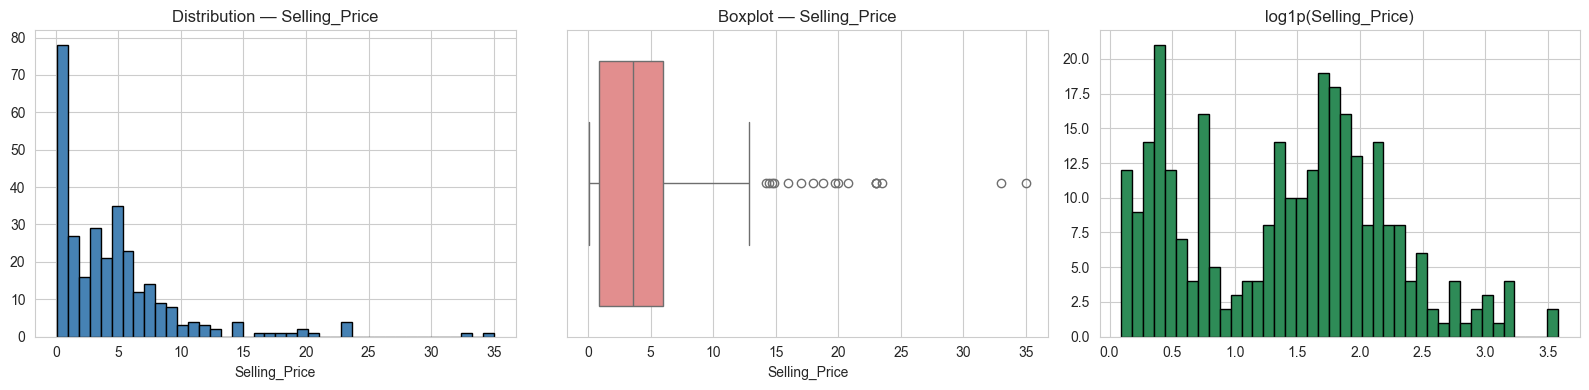

Skewness : 2.493
Kurtosis : 8.903
count    301.00
mean       4.66
std        5.08
min        0.10
25%        0.90
50%        3.60
75%        6.00
max       35.00
Name: Selling_Price, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(df['Selling_Price'].dropna(), bins=40, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution — Selling_Price')
axes[0].set_xlabel('Selling_Price')
sns.boxplot(x=df['Selling_Price'].dropna(), ax=axes[1], color='lightcoral')
axes[1].set_title('Boxplot — Selling_Price')
# Log scale (skewed targets)
axes[2].hist(np.log1p(df['Selling_Price'].dropna()), bins=40, color='seagreen', edgecolor='black')
axes[2].set_title('log1p(Selling_Price)')
plt.tight_layout(); plt.show()
print('Skewness :', round(df['Selling_Price'].skew(), 3))
print('Kurtosis :', round(df['Selling_Price'].kurtosis(), 3))
print(df['Selling_Price'].describe().round(2))

## 5. Univariate Analysis — Numeric Features

In [8]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'Selling_Price' in numeric_cols:
    numeric_cols.remove('Selling_Price')
print(f'Numeric features ({len(numeric_cols)}):')
print(numeric_cols[:30])

Numeric features (4):
['Year', 'Present_Price', 'Kms_Driven', 'Owner']


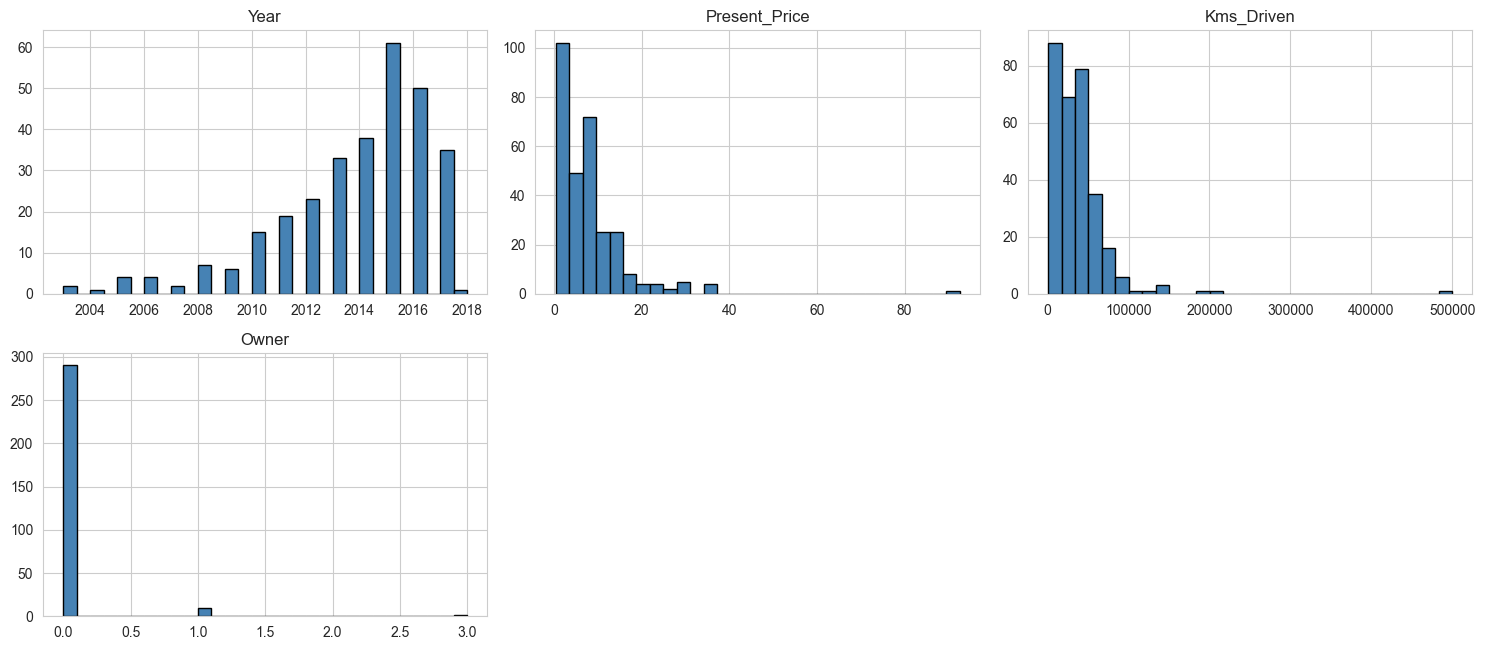

In [9]:
import math
n_show = min(len(numeric_cols), 12)
ncols = 3
nrows = math.ceil(n_show / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.3*nrows))
axes = np.array(axes).reshape(-1)
for i, col in enumerate(numeric_cols[:n_show]):
    df[col].hist(ax=axes[i], bins=30, color='steelblue', edgecolor='black')
    axes[i].set_title(col)
for j in range(n_show, len(axes)):
    axes[j].axis('off')
plt.tight_layout(); plt.show()

## 6. Bivariate Analysis — Features vs Target

In [10]:
corrs_all = df[numeric_cols + ['Selling_Price']].corr()['Selling_Price'].abs().sort_values(ascending=False)
top_features = [c for c in corrs_all.index if c != 'Selling_Price'][:6]
print('Top features by |correlation| with target:')
print(corrs_all[top_features].round(3))

Top features by |correlation| with target:
Present_Price    0.879
Year             0.236
Owner            0.088
Kms_Driven       0.029
Name: Selling_Price, dtype: float64


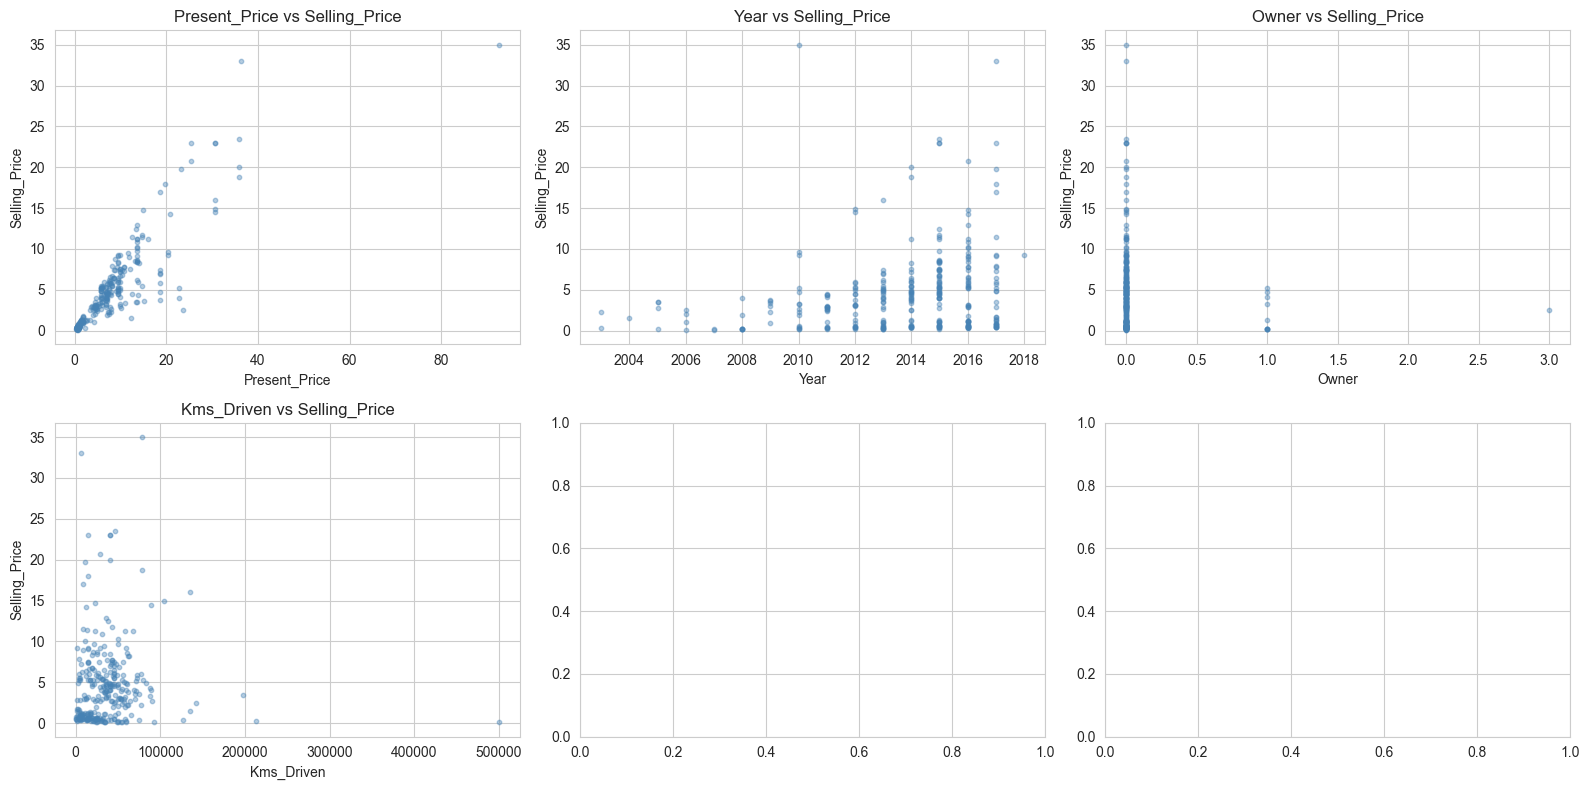

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(top_features[:6]):
    axes[i].scatter(df[col], df['Selling_Price'], alpha=0.4, s=10, color='steelblue')
    axes[i].set_xlabel(col); axes[i].set_ylabel('Selling_Price')
    axes[i].set_title(f'{col} vs Selling_Price')
plt.tight_layout(); plt.show()

## 7. Correlation Analysis

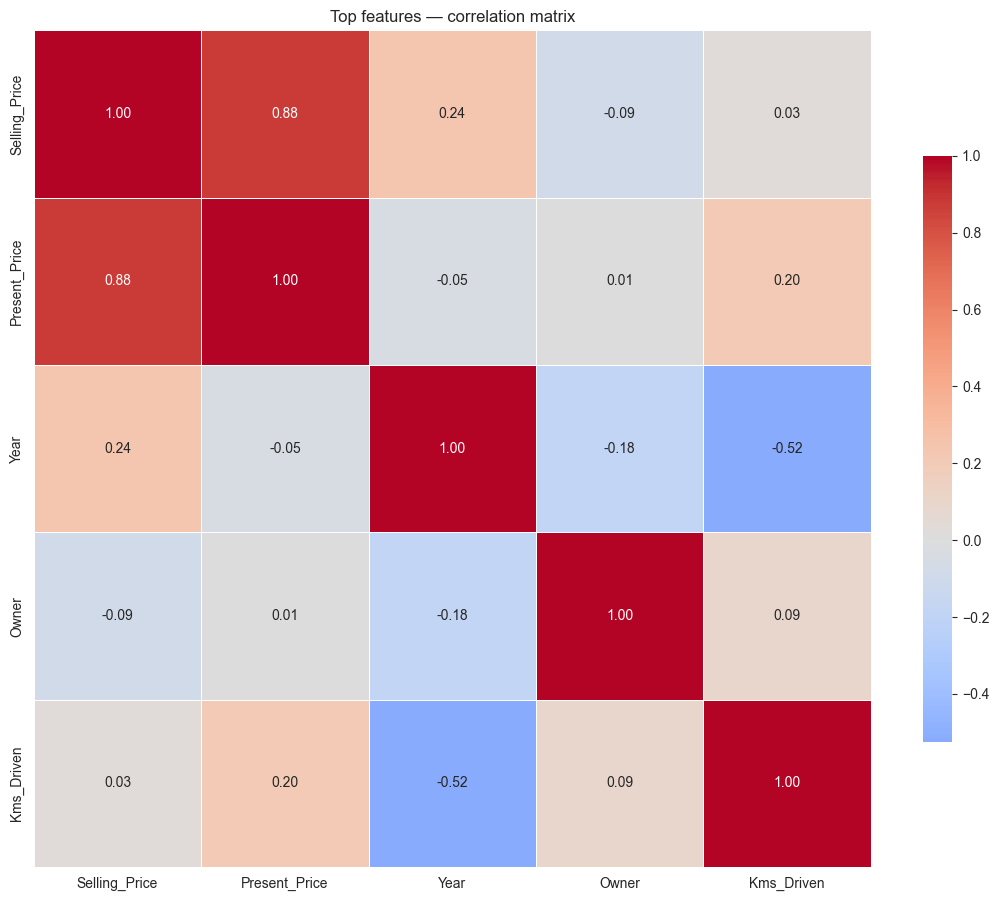

In [12]:
top_numeric = corrs_all.head(15).index.tolist()
if 'Selling_Price' not in top_numeric:
    top_numeric.append('Selling_Price')
corr_matrix = df[top_numeric].corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.7})
plt.title('Top features — correlation matrix'); plt.tight_layout(); plt.show()

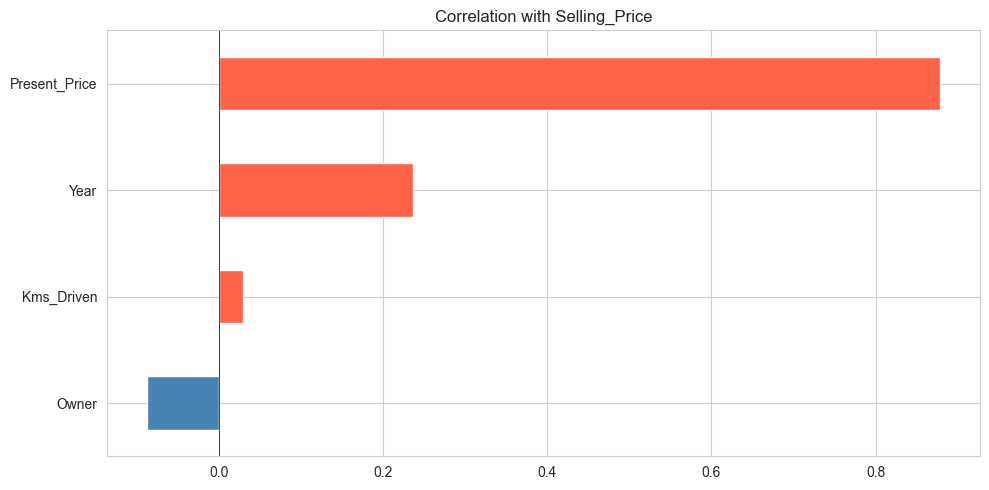

In [13]:
target_corr = df[numeric_cols + ['Selling_Price']].corr()['Selling_Price'].drop('Selling_Price').sort_values()
plt.figure(figsize=(10, max(5, len(target_corr)*0.25)))
colors = ['tomato' if v > 0 else 'steelblue' for v in target_corr]
target_corr.plot(kind='barh', color=colors)
plt.title('Correlation with Selling_Price')
plt.axvline(0, color='black', linewidth=0.5); plt.tight_layout(); plt.show()

## 8. Domain Deep-Dive — Fuel, Transmission, Owners

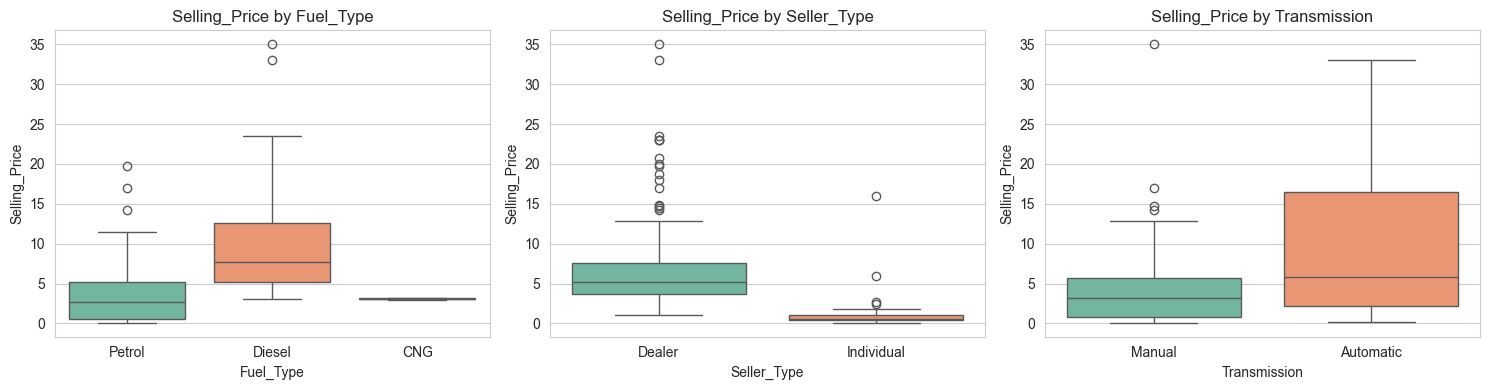

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Fuel_Type', 'Seller_Type', 'Transmission']):
    if col in df.columns:
        sns.boxplot(x=col, y='Selling_Price', data=df, ax=ax, palette='Set2')
        ax.set_title(f'Selling_Price by {col}')
plt.tight_layout(); plt.show()

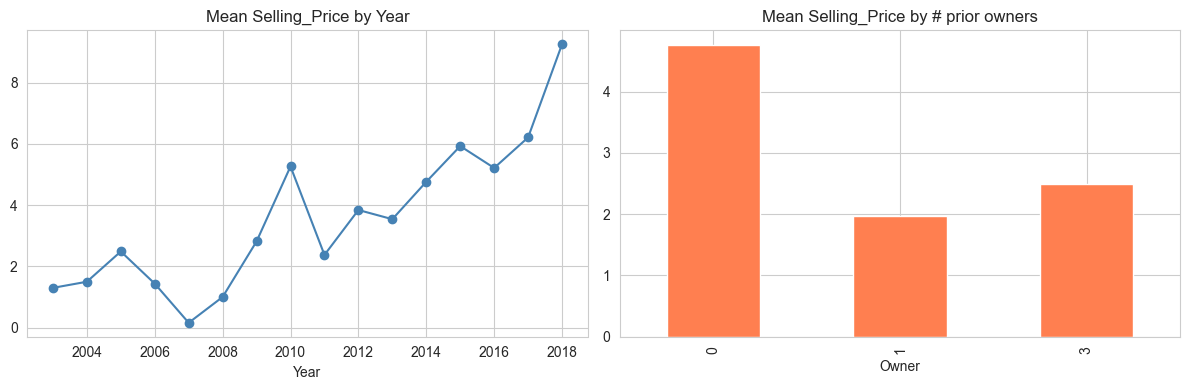

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
if 'Year' in df.columns:
    df.groupby('Year')['Selling_Price'].mean().plot(ax=axes[0], marker='o', color='steelblue')
    axes[0].set_title('Mean Selling_Price by Year')
if 'Owner' in df.columns:
    df.groupby('Owner')['Selling_Price'].mean().plot(kind='bar', ax=axes[1], color='coral')
    axes[1].set_title('Mean Selling_Price by # prior owners')
plt.tight_layout(); plt.show()

## 9. Pair Plot — Top Features

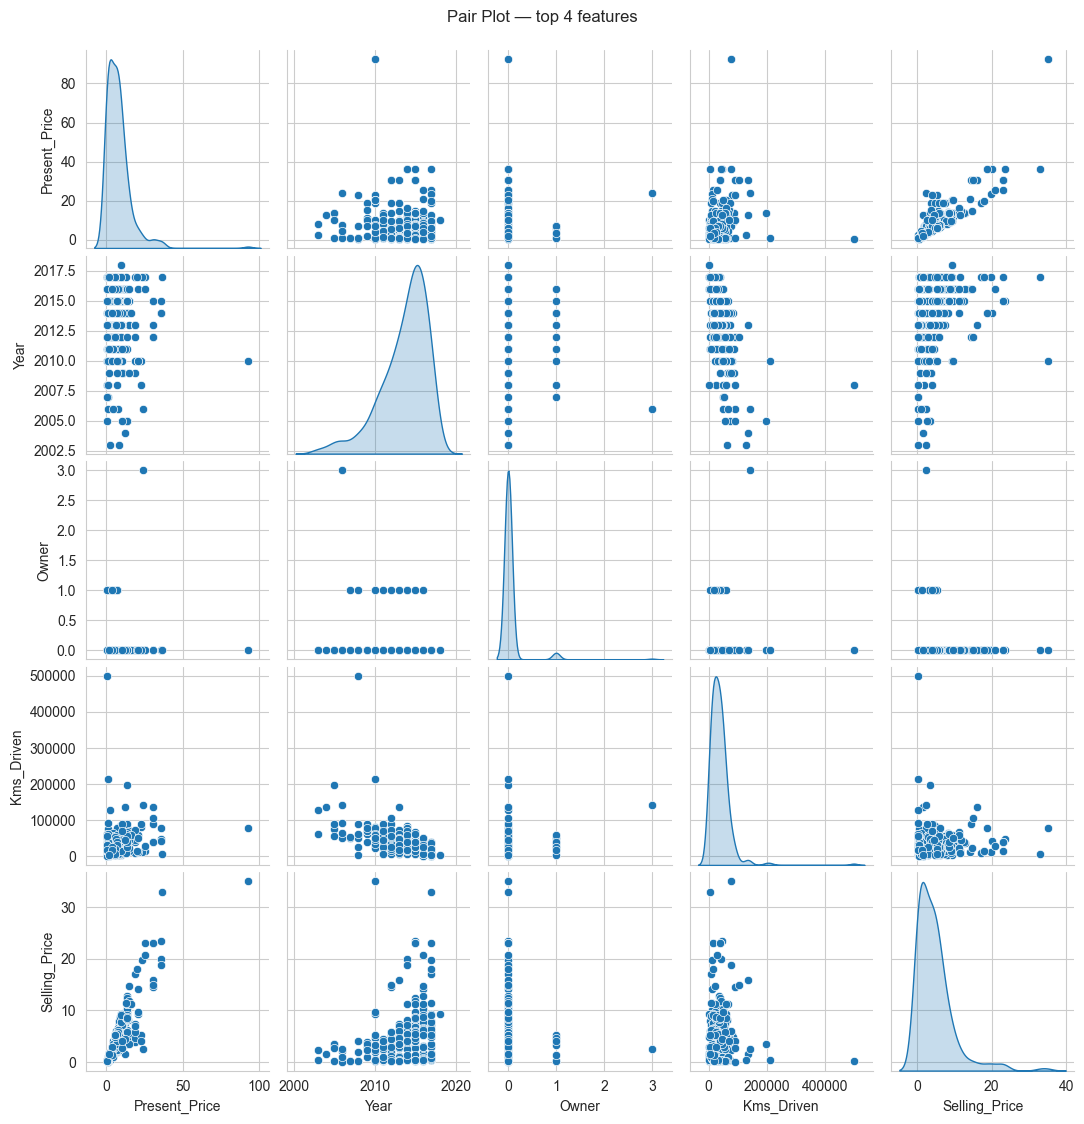

In [16]:
sample = df.sample(min(800, len(df)), random_state=42)
sns.pairplot(sample[top_features[:4] + ['Selling_Price']].dropna(), diag_kind='kde', height=2.2)
plt.suptitle('Pair Plot — top 4 features', y=1.02); plt.show()

## 10. Summary of Key Findings

In [17]:
summary = pd.DataFrame({
    'Metric': ['Total samples', 'Total features', 'Target mean', 'Target median',
               'Target stddev', 'Target min', 'Target max', 'Target skewness',
               'Top correlated feature', 'Top correlation value'],
    'Value': [
        len(df), df.shape[1] - 1,
        round(df['Selling_Price'].mean(), 2),
        round(df['Selling_Price'].median(), 2),
        round(df['Selling_Price'].std(), 2),
        round(df['Selling_Price'].min(), 2),
        round(df['Selling_Price'].max(), 2),
        round(df['Selling_Price'].skew(), 3),
        top_features[0],
        round(corrs_all[top_features[0]], 3),
    ],
})
summary

,Metric,Value
0,Total samples,301
1,Total features,8
2,Target mean,4.66
3,Target median,3.6
4,Target stddev,5.08
5,Target min,0.1
6,Target max,35.0
7,Target skewness,2.493
8,Top correlated feature,Present_Price
9,Top correlation value,0.879
